## D2S Test functionals for the lower bounds for TV-distance

The following two specific tests show numerically that the TV-approximation rates for the Euler and the Milshtein schemes are not better than $h_n^0$ and $h_n^{1/2}$, respectively: Here $X$ will be Euler and Milshteinand 1.5 scheme and the true solution, actually First we define the functionals

$$
D_1(n,X) := \sum_{k=1}^{n} \Delta^1(h_n, X_{t_{k-1}}, X_{t_k}) - \frac{1}{2} \sum_{k=1}^{n} \left[\Delta^1(h_n, X_{t_{k-1}}, X_{t_k})\right]^2 \tag{D1}
$$

$$
D_2(n,X) := \sum_{k=1}^{n} \Delta^2(h_n, X_{t_{k-1}}, X_{t_k}) \tag{D2}
$$

$$
F_n^E(X) = \text{sgn}\,(D_1(n,X)) \tag{D1S}
$$

$$
F_n^M(X) = h_n^{-1/2}\text{sgn}\,(D_2(n,X)), \tag{D2S -- Error Formula}
$$

$$
F_n^M(X) = \text{sgn}\,(D_2(n,X)), \tag{D2S\_nodt -- \text{\red{Check Formula}}}
$$

Similarly, we expect to observe that  

$$
\mathbb{E}\!\left[ F_n^{M}(X^{1,[n]}) - F_n^{M}(X^{[n]}) \right] \rightarrow \mathbb{E}|I_T^{1}|, \tag{D2S$\Delta$}
$$
where,

$$
I_T^{1} = \sqrt{2}\int_0^T |c_2^2||b|^{-1}(X(s))\, dW_s^{(2)} 
+ \sqrt{4!}\int_0^T |c_4^2|\, b^{-2}(X(s))\, dW_s^{(4)}
$$

$$
c_4^2(x) = \frac{1}{12} b''(x)b(x)^2
$$

$$
c_2^2(x) = \frac{1}{2} a'(x)b(x) + \frac{1}{4} b'(x)a(x) 
+ \frac{1}{8} b''(x)b(x) - \frac{1}{16} b'(x)^2.
$$

## M1 Models


### D1F1M1_check

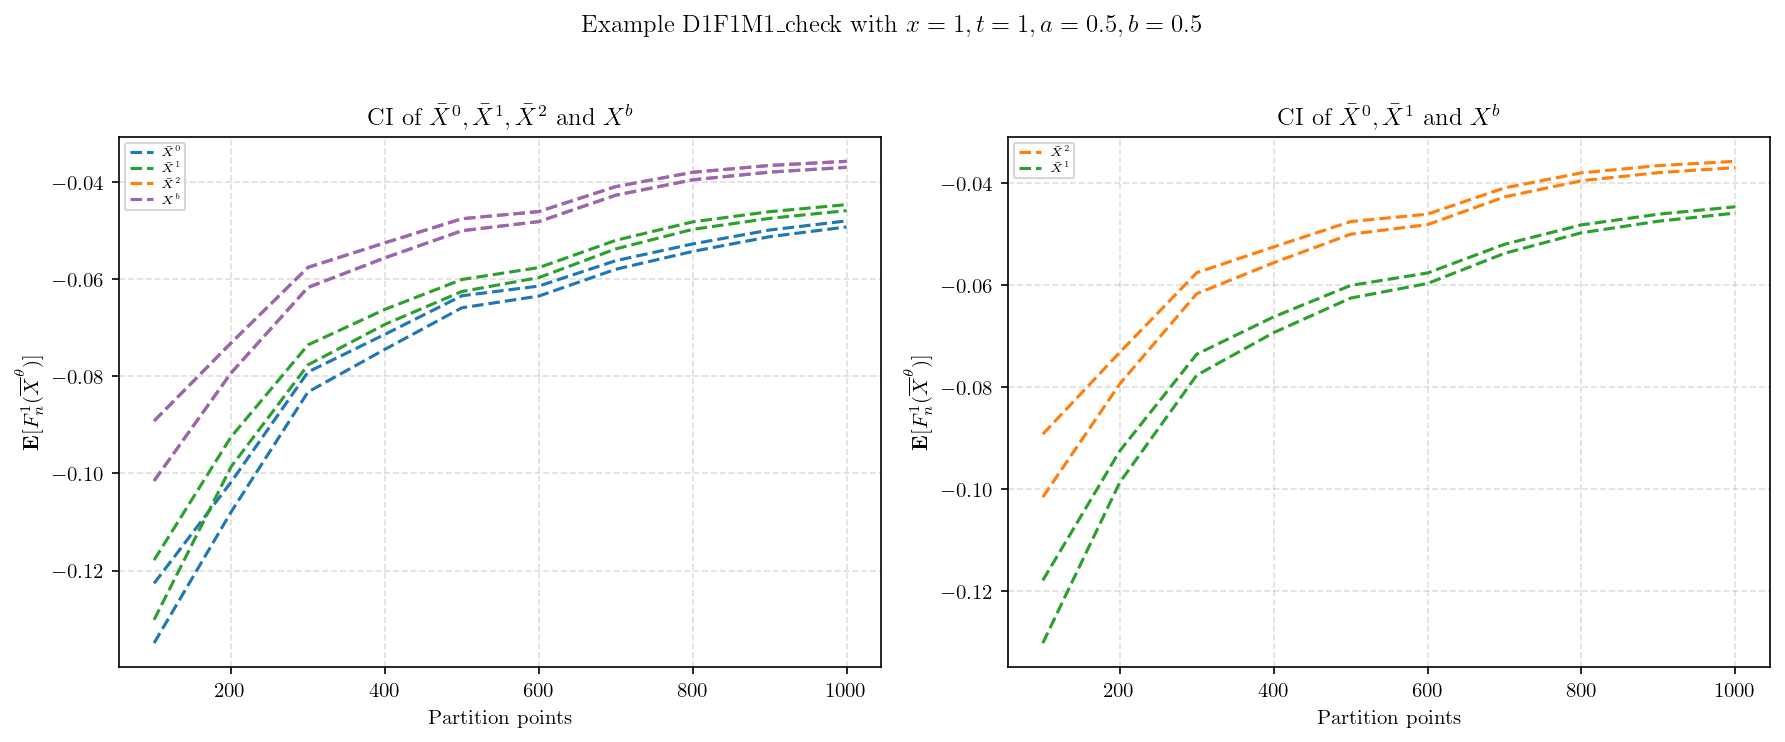

image saved to: sim_pics/D1F1M1_check_nodt_100_1000_subplot.png


In [31]:
#D1F1M1_check_nodt_100_1000
#信頼区間公式 \bar{X} ± z * (s/√n) 
# ここで、\bar{X}は標本平均、zは信頼水準、sは標本標準偏差(SD)、nはサンプルサイズ(SS),(s/√n)は標準誤差(SE)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from pathlib import Path
plt.rcParams['font.family'] = 'Hiragino Sans'  # 図のフォント設定
save_dir = Path("sim_pics")  # フォルダー保存先
save_dir.mkdir(exist_ok=True)

save_path = save_dir / "D1F1M1_check_nodt_100_1000_subplot.png"  # 画像保存パス（ファイル名だけ変更）

# 信頼水準(confidence level)の関数
def conf_level(a):  # aは信頼度であり、ex:a=0.95なら95%信頼区間
    alpha = 1-a
    z = norm.ppf(1 - alpha / 2)
    return z

df2 = pd.read_csv("../data_source/D2SM1_check_nodt_100_1000_data.csv")

# z信頼水準の計算,aは信頼度であり、ex:a=0.95なら95%信頼区間
a = 0.95
z = conf_level(a)

A_std_df2   = np.sqrt(df2['E'])      # Aの標本標準偏差(SD)
Am_std_df2  = np.sqrt(df2['Em'])     # Amの標本標準偏差(SD)
A15_std_df2 = np.sqrt(df2['E_1_5'])  # A_1_5の標本標準偏差(SD)
Axb_std_df2 = np.sqrt(df2['Eb'])     # A_bの標本標準偏差(SD)

paths = 10 * (df2['points'] ** 2)

# Standard errors of sample means
A_se_df2     = A_std_df2   / np.sqrt(paths)
Am_se_df2    = Am_std_df2  / np.sqrt(paths)
A15_se_df2   = A15_std_df2 / np.sqrt(paths)
Axb_se_df2   = Axb_std_df2 / np.sqrt(paths)

# Confidence bands
A_up_df2     = df2['A']      + z * A_se_df2
A_low_df2    = df2['A']      - z * A_se_df2
Am_up_df2    = df2['Am']     + z * Am_se_df2
Am_low_df2   = df2['Am']     - z * Am_se_df2
A15_up_df2   = df2['A_1_5']  + z * A15_se_df2
A15_low_df2  = df2['A_1_5']  - z * A15_se_df2
Axb_up_df2   = df2['Ab']     + z * Axb_se_df2
Axb_low_df2  = df2['Ab']     - z * Axb_se_df2

# ---------- ここから subplot で 2 枚の図を描画 ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

# ===== 左側の図：元の3種類の信頼区間 =====
ax1 = axes[0]
ax1.plot(df2["points"], A_up_df2,  linestyle="--", color="#1f77b4", label=r"$\bar{X}^{0}$")
ax1.plot(df2["points"], A_low_df2, linestyle="--", color="#1f77b4")
ax1.plot(df2["points"], Am_up_df2,  linestyle="--", color="#2ca02c", label=r"$\bar{X}^{1}$")
ax1.plot(df2["points"], Am_low_df2, linestyle="--", color="#2ca02c")
ax1.plot(df2["points"], A15_up_df2,  linestyle="--", color="#ff7f0e", label=r"$\bar{X}^{2}$")
ax1.plot(df2["points"], A15_low_df2, linestyle="--", color="#ff7f0e")
ax1.plot(df2["points"], Axb_up_df2,  linestyle="--", color="#9467bd", label=r"$X^{b}$")
ax1.plot(df2["points"], Axb_low_df2, linestyle="--", color="#9467bd")

ax1.set_title(r'CI of $\bar{X}^{0}, \bar{X}^{1}, \bar{X}^{2}$ and $X^{b}$')
ax1.set_xlabel("Partition points")
ax1.set_ylabel(r'$\mathbf{E}[F^1_{n}(\overline{X}^\theta)]$')
ax1.grid(True, linestyle="--", alpha=0.4)
ax1.legend(fontsize=5.5, loc='best')

# ===== 右側の図：指定された4本の線の図 =====
ax2 = axes[1]
ax2.plot(df2["points"], A15_up_df2,  linestyle="--", color="#ff7f0e", label=r"$\bar{X}^{2}$")
ax2.plot(df2["points"], A15_low_df2, linestyle="--", color="#ff7f0e")
# ax2.plot(df2["points"], Axb_up_df2,  linestyle="--", color="#9467bd", label=r"$\bar{X}^{b}$")
# ax2.plot(df2["points"], Axb_low_df2, linestyle="--", color="#9467bd")
ax2.plot(df2["points"], Am_up_df2,  linestyle="--", color="#2ca02c", label=r"$\bar{X}^{1}$")
ax2.plot(df2["points"], Am_low_df2, linestyle="--", color="#2ca02c")

ax2.set_title(r'CI of $\bar{X}^{0},\bar{X}^{1}$ and $X^{b}$')
ax2.set_xlabel("Partition points")
ax2.set_ylabel(r'$\mathbf{E}[F^1_{n}(\overline{X}^\theta)]$')
ax2.grid(True, linestyle="--", alpha=0.4)
ax2.legend(fontsize=5.5, loc='best')

# 全体タイトル（必要なら）
fig.suptitle(r'Example D1F1M1_check with $x=1,t=1,a=0.5,b=0.5$')

plt.tight_layout(rect=[0, 0, 1, 0.95])  # 上に suptitle を置くために rect を少し縮める
plt.savefig(save_path, dpi=250, bbox_inches='tight')
plt.show()
print("image saved to:", save_path)

### D1F1M1_check_Var

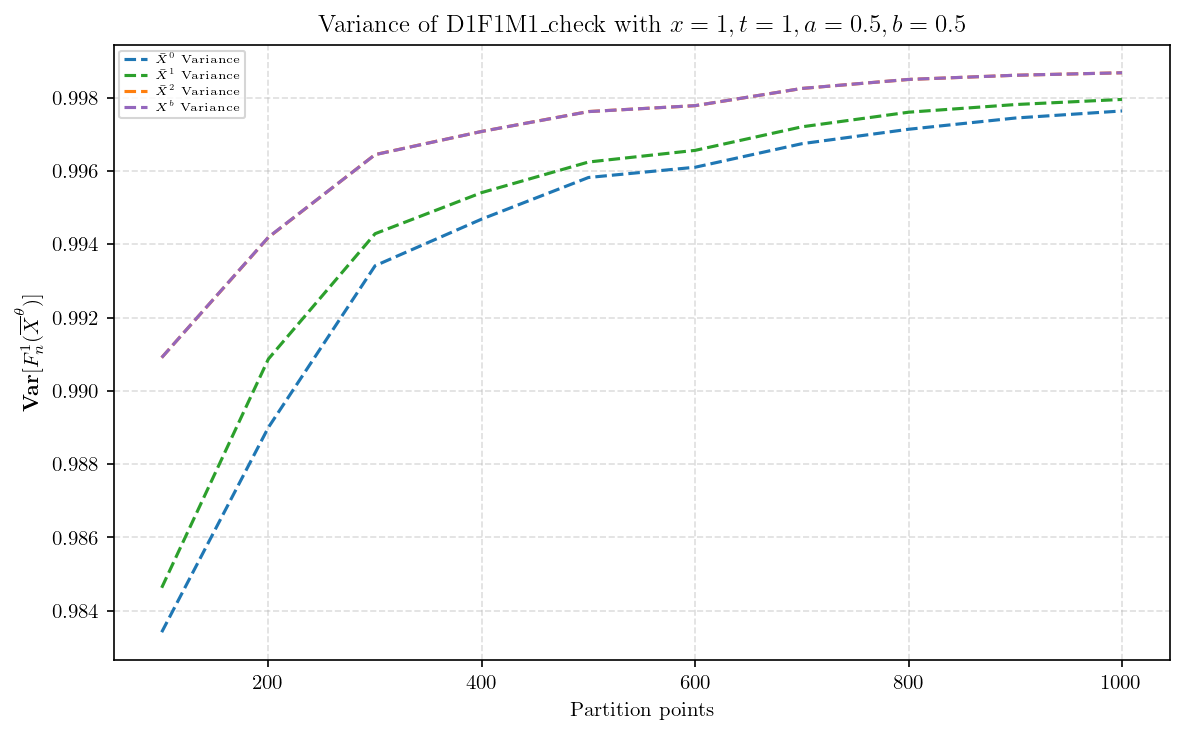

In [32]:
#D1F1M1_check_nodt variance plot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
plt.rcParams['font.family'] = 'Hiragino Sans'  # 図のフォント設定
df = pd.read_csv("../data_source/D2SM1_check_nodt_100_1000_data.csv")

#分散
variance_A = df['E']
variance_Am = df['Em']
variance_A15 = df['E_1_5']
variance_Ab = df['Eb']

plt.figure(figsize=(8, 5), dpi=150)  # dpi とは Dots Per Inch を意味する
plt.plot(df["points"], variance_A, linestyle="--", color="#1f77b4", label=r"$\bar{X}^{0}$ Variance")
plt.plot(df["points"], variance_Am, linestyle="--", color="#2ca02c", label=r"$\bar{X}^{1}$ Variance")
plt.plot(df["points"], variance_A15, linestyle="--", color="#ff7f0e", label=r"$\bar{X}^{2}$ Variance")
plt.plot(df["points"], variance_Ab, linestyle="--", color="#9467bd", label=r"$X^{b}$ Variance")    
plt.title(r'Variance of D1F1M1_check with $x=1,t=1,a=0.5,b=0.5$')
plt.xlabel("Partition points")
plt.ylabel(r'$\mathbf{Var}[F^1_{n}(\overline{X}^\theta)]$')
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(fontsize=5.5, loc='best')
plt.tight_layout()  # 自動的にレイアウトを調整する


### D1F1M1

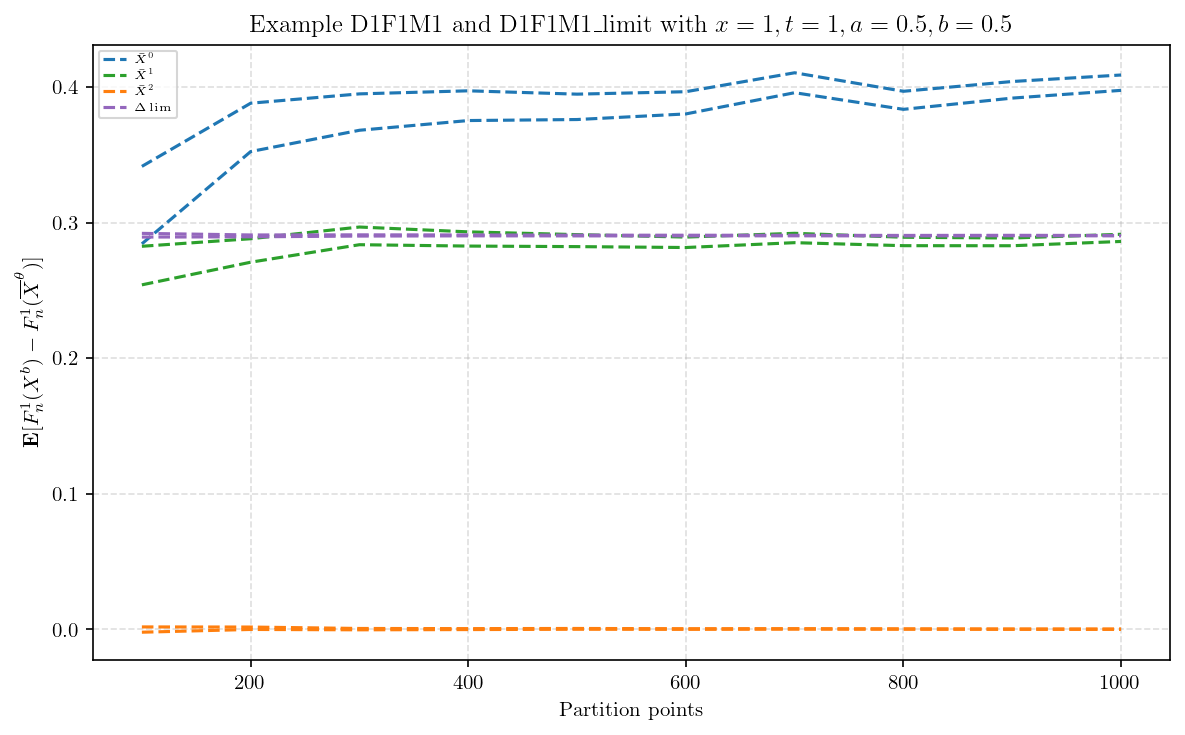

image saved to: sim_pics/D1F1M1_and_limit_100_1000.png


In [33]:
#D1F1M1_all_100_1000 plot with confidence intervals
#信頼区間公式 \bar{X} ± z * (s/√n) 
# ここで、\bar{X}は標本平均、zは信頼水準、sは標本標準偏差(SD)、nはサンプルサイズ(SS),(s/√n)は標準誤差(SE)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from pathlib import Path
plt.rcParams['font.family'] = 'Hiragino Sans'  # 図のフォント設定
save_dir = Path("sim_pics")# フォルダー保存先
save_dir.mkdir(exist_ok=True)

save_path = save_dir / "D1F1M1_and_limit_100_1000.png" #画像保存パス

#信頼水準(confidence level)の関数
def conf_level(a): #aは信頼度であり、ex:a=0.95なら95%信頼区間
    alpha = 1-a #aが0.95なら、alpha=0.05となり（全体の5%が信頼区間外になる）,外側（両端）にある確率の合計である
    z=norm.ppf(1 - alpha / 2) #ここでPPF = Percaent Point Function,両側検定なのでalpha/2,norm.ppfは累積分布関数の逆関数、i.e.「何番目の値がこの累積確率になるのか？」を計算する
    return z

df2 = pd.read_csv("../data_source/D2SM1_all_100_1000_data.csv")
df3 = pd.read_csv("../data_source/D2SM1_all_100_1000_data.csv")


#z信頼水準の計算,aは信頼度であり、ex:a=0.95なら95%信頼区間
a=0.95 #ここで信頼度を設定する
z=conf_level(a)
A_std_df2=np.sqrt(df2['E']) #Aの標本標準偏差(SD)
Am_std_df2=np.sqrt(df2['Em']) #Amの標本標準偏差(SD)
A15_std_df2=np.sqrt(df2['E_1_5']) #A_1_5の標本標準偏差(SD)
Axb_std_df3 = np.sqrt(df3['Eb']) #A_bの標本標準偏差(SD)

paths = 10 * (df2['points'] ** 2)
# Standard errors of sample means
A_se_df2     = A_std_df2   / np.sqrt(paths)
Am_se_df2    = Am_std_df2  / np.sqrt(paths)
A15_se_df2   = A15_std_df2 / np.sqrt(paths)
Axb_se_df3   = Axb_std_df3 / np.sqrt(paths)

# Confidence bands
A_up_df2     = df2['A']     + z * A_se_df2
A_low_df2    = df2['A']     - z * A_se_df2
Am_up_df2    = df2['Am']    + z * Am_se_df2
Am_low_df2   = df2['Am']    - z * Am_se_df2
A15_up_df2   = df2['A_1_5'] + z * A15_se_df2
A15_low_df2  = df2['A_1_5'] - z * A15_se_df2
Axb_up_df3   = df3['Ab'] + z * Axb_se_df3
Axb_low_df3  = df3['Ab'] - z * Axb_se_df3


# グラフを描画
plt.figure(figsize=(8, 5), dpi=150)  # dpi とは Dots Per Inch を意味する
plt.plot(df2["points"], A_up_df2, linestyle="--", color="#1f77b4", label=r"$\bar{X}^{0}$")
plt.plot(df2["points"], A_low_df2, linestyle="--", color="#1f77b4")  
plt.plot(df2["points"], Am_up_df2, linestyle="--", color="#2ca02c", label=r"$\bar{X}^{1}$ ")
plt.plot(df2["points"], Am_low_df2, linestyle="--", color="#2ca02c")  
plt.plot(df2["points"], A15_up_df2, linestyle="--", color="#ff7f0e", label=r"$\bar{X}^{2}$ ")
plt.plot(df2["points"], A15_low_df2, linestyle="--", color="#ff7f0e")
plt.plot(df3["points"], Axb_up_df3, linestyle="--", color="#9467bd", label=r"$\Delta\lim$ ")
plt.plot(df3["points"], Axb_low_df3, linestyle="--", color="#9467bd")


plt.title(r'Example D1F1M1 and D1F1M1_limit with $x=1,t=1,a=0.5,b=0.5$')
plt.xlabel("Partition points")
plt.ylabel(r'$\mathbf{E}[F^1_{n}(X^b) - F^1_{n}(\overline{X}^\theta)]$')
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(fontsize=5.5, loc='best')
plt.tight_layout()  # 自動的にレイアウトを調整する
plt.savefig(save_path, dpi=250, bbox_inches='tight')
plt.show()
print("image saved to:", save_path)

### D1F1M1_Var

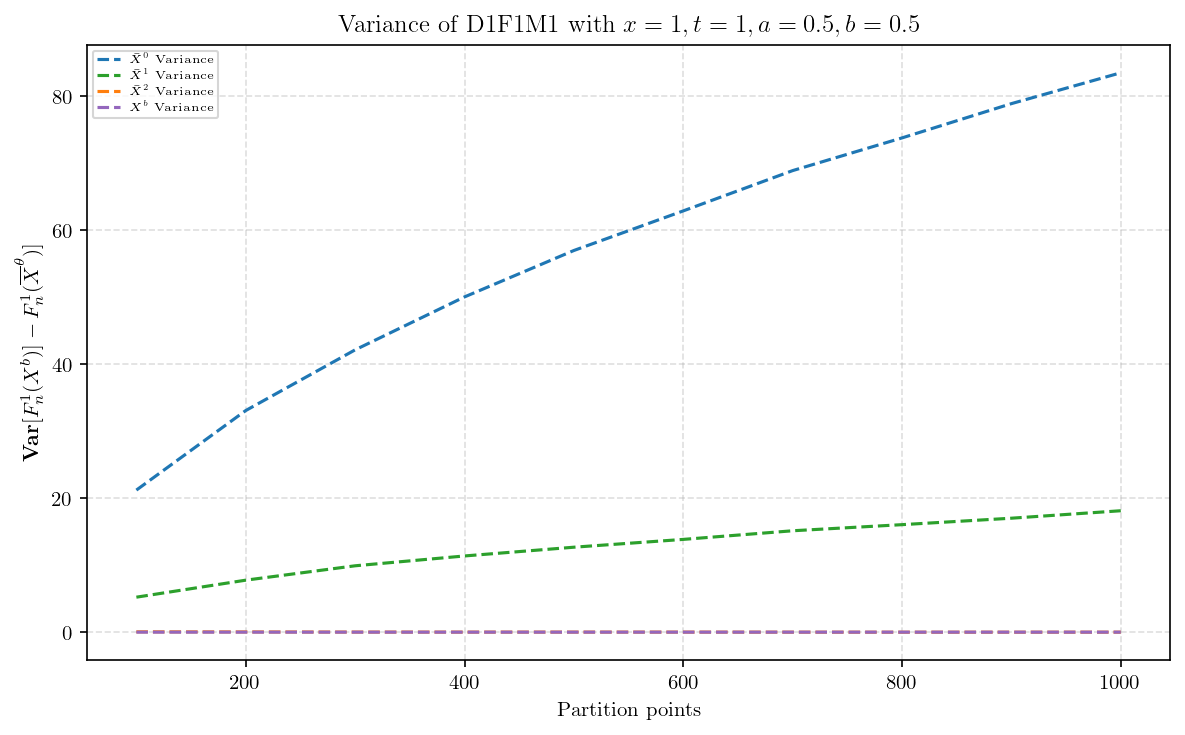

In [34]:
#D1F1M1 variance plot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
plt.rcParams['font.family'] = 'Hiragino Sans'  # 図のフォント設定
df = pd.read_csv("../data_source/D2SM1_all_100_1000_data.csv")

#分散
variance_A = df['E']
variance_Am = df['Em']
variance_A15 = df['E_1_5']
variance_Ab = df['Eb']

plt.figure(figsize=(8, 5), dpi=150)  # dpi とは Dots Per Inch を意味する
plt.plot(df["points"], variance_A, linestyle="--", color="#1f77b4", label=r"$\bar{X}^{0}$ Variance")
plt.plot(df["points"], variance_Am, linestyle="--", color="#2ca02c", label=r"$\bar{X}^{1}$ Variance")
plt.plot(df["points"], variance_A15, linestyle="--", color="#ff7f0e", label=r"$\bar{X}^{2}$ Variance")
plt.plot(df["points"], variance_Ab, linestyle="--", color="#9467bd", label=r"$X^{b}$ Variance")    
plt.title(r'Variance of D1F1M1 with $x=1,t=1,a=0.5,b=0.5$')
plt.xlabel("Partition points")
plt.ylabel(r'$\mathbf{Var}[F^1_{n}(X^b)] - F^1_{n}(\overline{X}^\theta)]$')
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(fontsize=5.5, loc='best')
plt.tight_layout()  # 自動的にレイアウトを調整する


## M2 Models

### D1F1M2_check

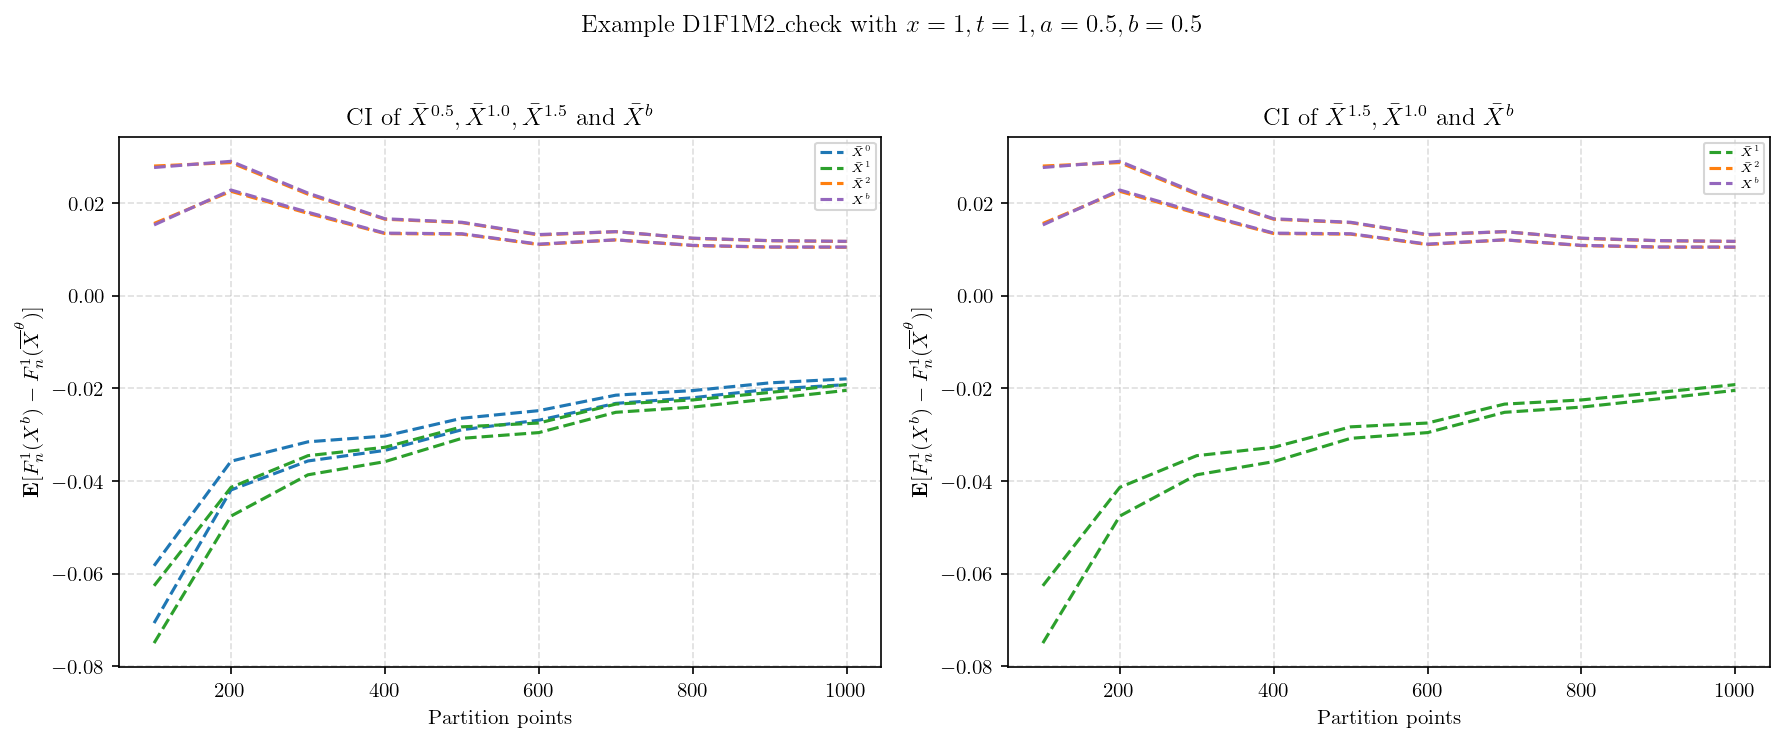

image saved to: sim_pics/D1F1M2_check_nodt_100_1000_subplot.png


In [35]:
#D1F1M2_check_nodt_100_1000
#信頼区間公式 \bar{X} ± z * (s/√n) 
# ここで、\bar{X}は標本平均、zは信頼水準、sは標本標準偏差(SD)、nはサンプルサイズ(SS),(s/√n)は標準誤差(SE)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from pathlib import Path
plt.rcParams['font.family'] = 'Hiragino Sans'  # 図のフォント設定
save_dir = Path("sim_pics")  # フォルダー保存先
save_dir.mkdir(exist_ok=True)

save_path = save_dir / "D1F1M2_check_nodt_100_1000_subplot.png"  # 画像保存パス（ファイル名だけ変更）

# 信頼水準(confidence level)の関数
def conf_level(a):  # aは信頼度であり、ex:a=0.95なら95%信頼区間
    alpha = 1-a
    z = norm.ppf(1 - alpha / 2)
    return z

df2 = pd.read_csv("../data_source/D2SM2_check_nodt_100_1000_data.csv")

# z信頼水準の計算,aは信頼度であり、ex:a=0.95なら95%信頼区間
a = 0.95
z = conf_level(a)

A_std_df2   = np.sqrt(df2['E'])      # Aの標本標準偏差(SD)
Am_std_df2  = np.sqrt(df2['Em'])     # Amの標本標準偏差(SD)
A15_std_df2 = np.sqrt(df2['E_1_5'])  # A_1_5の標本標準偏差(SD)
Axb_std_df2 = np.sqrt(df2['Eb'])     # A_bの標本標準偏差(SD)

paths = 10 * (df2['points'] ** 2)

# Standard errors of sample means
A_se_df2     = A_std_df2   / np.sqrt(paths)
Am_se_df2    = Am_std_df2  / np.sqrt(paths)
A15_se_df2   = A15_std_df2 / np.sqrt(paths)
Axb_se_df2   = Axb_std_df2 / np.sqrt(paths)

# Confidence bands
A_up_df2     = df2['A']      + z * A_se_df2
A_low_df2    = df2['A']      - z * A_se_df2
Am_up_df2    = df2['Am']     + z * Am_se_df2
Am_low_df2   = df2['Am']     - z * Am_se_df2
A15_up_df2   = df2['A_1_5']  + z * A15_se_df2
A15_low_df2  = df2['A_1_5']  - z * A15_se_df2
Axb_up_df2   = df2['Ab']     + z * Axb_se_df2
Axb_low_df2  = df2['Ab']     - z * Axb_se_df2

# ---------- ここから subplot で 2 枚の図を描画 ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

# ===== 左側の図：元の3種類の信頼区間 =====
ax1 = axes[0]
ax1.plot(df2["points"], A_up_df2,  linestyle="--", color="#1f77b4", label=r"$\bar{X}^{0}$")
ax1.plot(df2["points"], A_low_df2, linestyle="--", color="#1f77b4")
ax1.plot(df2["points"], Am_up_df2,  linestyle="--", color="#2ca02c", label=r"$\bar{X}^{1}$")
ax1.plot(df2["points"], Am_low_df2, linestyle="--", color="#2ca02c")
ax1.plot(df2["points"], A15_up_df2,  linestyle="--", color="#ff7f0e", label=r"$\bar{X}^{2}$")
ax1.plot(df2["points"], A15_low_df2, linestyle="--", color="#ff7f0e")
ax1.plot(df2["points"], Axb_up_df2,  linestyle="--", color="#9467bd", label=r"$X^{b}$")
ax1.plot(df2["points"], Axb_low_df2, linestyle="--", color="#9467bd")

ax1.set_title(r'CI of $\bar{X}^{0.5}, \bar{X}^{1.0}, \bar{X}^{1.5}$ and $\bar{X}^{b}$')
ax1.set_xlabel("Partition points")
ax1.set_ylabel(r'$\mathbf{E}[F^1_{n}(X^b) - F^1_{n}(\overline{X}^\theta)]$')
ax1.grid(True, linestyle="--", alpha=0.4)
ax1.legend(fontsize=5.5, loc='best')

# ===== 右側の図：指定された4本の線の図 =====
ax2 = axes[1]
ax2.plot(df2["points"], Am_up_df2,  linestyle="--", color="#2ca02c", label=r"$\bar{X}^{1}$")
ax2.plot(df2["points"], Am_low_df2, linestyle="--", color="#2ca02c")
ax2.plot(df2["points"], A15_up_df2,  linestyle="--", color="#ff7f0e", label=r"$\bar{X}^{2}$")
ax2.plot(df2["points"], A15_low_df2, linestyle="--", color="#ff7f0e")
ax2.plot(df2["points"], Axb_up_df2,  linestyle="--", color="#9467bd", label=r"$X^{b}$")
ax2.plot(df2["points"], Axb_low_df2, linestyle="--", color="#9467bd")


ax2.set_title(r'CI of $\bar{X}^{1.5},\bar{X}^{1.0}$ and $\bar{X}^{b}$')
ax2.set_xlabel("Partition points")
ax2.set_ylabel(r'$\mathbf{E}[F^1_{n}(X^b) - F^1_{n}(\overline{X}^\theta)]$')
ax2.grid(True, linestyle="--", alpha=0.4)
ax2.legend(fontsize=5.5, loc='best')

# 全体タイトル（必要なら）
fig.suptitle(r'Example D1F1M2_check with $x=1,t=1,a=0.5,b=0.5$')

plt.tight_layout(rect=[0, 0, 1, 0.95])  # 上に suptitle を置くために rect を少し縮める
plt.savefig(save_path, dpi=250, bbox_inches='tight')
plt.show()
print("image saved to:", save_path)

### D1F1M2_check_Var

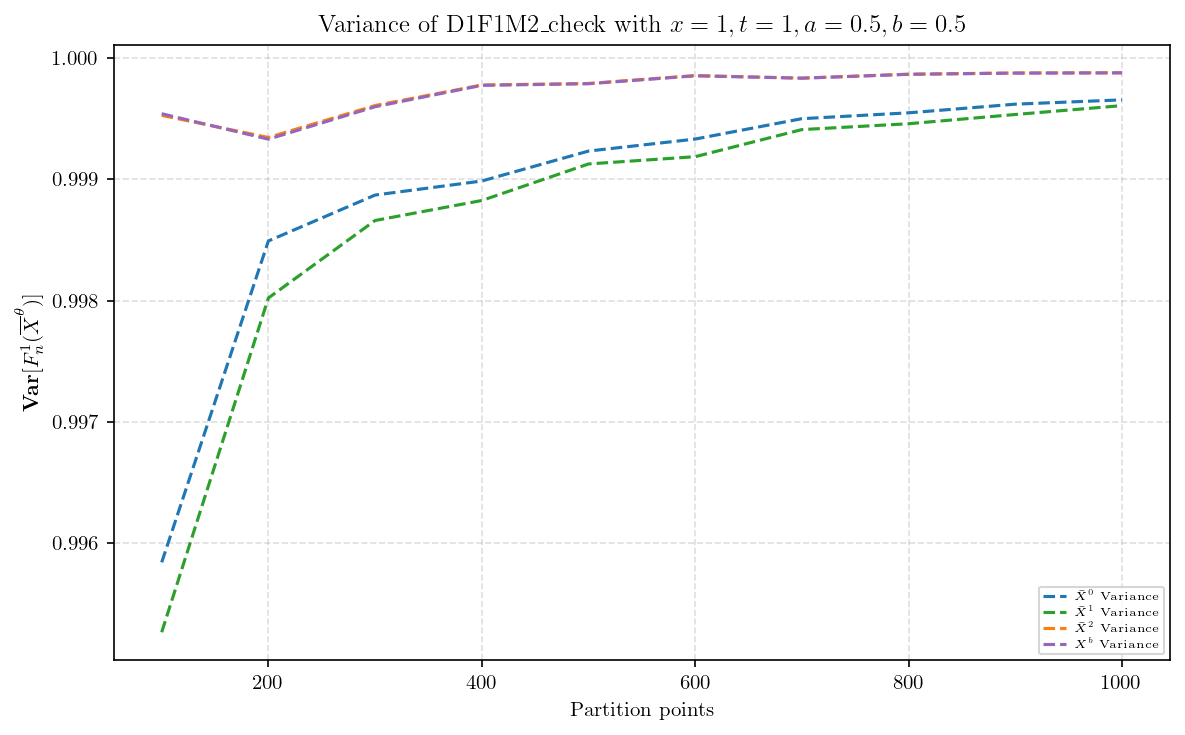

In [36]:
#D1F1M2_check_nodt variance plot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
plt.rcParams['font.family'] = 'Hiragino Sans'  # 図のフォント設定
df = pd.read_csv("../data_source/D2SM2_check_nodt_100_1000_data.csv")

#分散
variance_A = df['E']
variance_Am = df['Em']
variance_A15 = df['E_1_5']
variance_Ab = df['Eb']

plt.figure(figsize=(8, 5), dpi=150)  # dpi とは Dots Per Inch を意味する
plt.plot(df["points"], variance_A, linestyle="--", color="#1f77b4", label=r"$\bar{X}^{0}$ Variance")
plt.plot(df["points"], variance_Am, linestyle="--", color="#2ca02c", label=r"$\bar{X}^{1}$ Variance")
plt.plot(df["points"], variance_A15, linestyle="--", color="#ff7f0e", label=r"$\bar{X}^{2}$ Variance")
plt.plot(df["points"], variance_Ab, linestyle="--", color="#9467bd", label=r"$X^{b}$ Variance")    
plt.title(r'Variance of D1F1M2_check with $x=1,t=1,a=0.5,b=0.5$')
plt.xlabel("Partition points")
plt.ylabel(r'$\mathbf{Var}[F^1_{n}(\overline{X}^\theta)]$')
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(fontsize=5.5, loc='best')
plt.tight_layout()  # 自動的にレイアウトを調整する


### D1F1M2

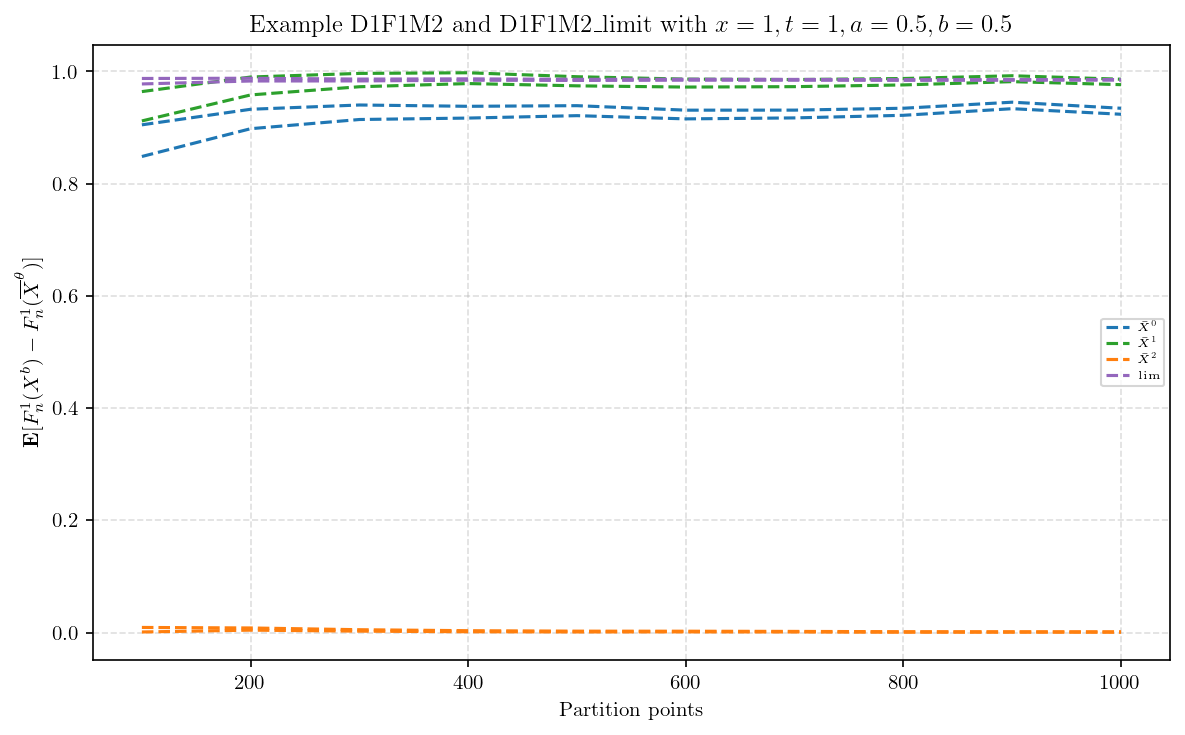

image saved to: sim_pics/D1F1M2_and_limit_100_1000.png


In [37]:
#D1F1M2_all_100_1000 plot with confidence intervals
#信頼区間公式 \bar{X} ± z * (s/√n) 
# ここで、\bar{X}は標本平均、zは信頼水準、sは標本標準偏差(SD)、nはサンプルサイズ(SS),(s/√n)は標準誤差(SE)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from pathlib import Path
plt.rcParams['font.family'] = 'Hiragino Sans'  # 図のフォント設定
save_dir = Path("sim_pics")# フォルダー保存先
save_dir.mkdir(exist_ok=True)

save_path = save_dir / "D1F1M2_and_limit_100_1000.png" #画像保存パス

#信頼水準(confidence level)の関数
def conf_level(a): #aは信頼度であり、ex:a=0.95なら95%信頼区間
    alpha = 1-a #aが0.95なら、alpha=0.05となり（全体の5%が信頼区間外になる）,外側（両端）にある確率の合計である
    z=norm.ppf(1 - alpha / 2) #ここでPPF = Percaent Point Function,両側検定なのでalpha/2,norm.ppfは累積分布関数の逆関数、i.e.「何番目の値がこの累積確率になるのか？」を計算する
    return z

df2 = pd.read_csv("../data_source/D2SM2_all_100_1000_data.csv")
df3 = pd.read_csv("../data_source/D2SM2_all_100_1000_data.csv")


#z信頼水準の計算,aは信頼度であり、ex:a=0.95なら95%信頼区間
a=0.95 #ここで信頼度を設定する
z=conf_level(a)
A_std_df2=np.sqrt(df2['E']) #Aの標本標準偏差(SD)
Am_std_df2=np.sqrt(df2['Em']) #Amの標本標準偏差(SD)
A15_std_df2=np.sqrt(df2['E_1_5']) #A_1_5の標本標準偏差(SD)
Axb_std_df3 = np.sqrt(df3['Eb']) #A_bの標本標準偏差(SD)

paths = 10 * (df2['points'] ** 2)
# Standard errors of sample means
A_se_df2     = A_std_df2   / np.sqrt(paths)
Am_se_df2    = Am_std_df2  / np.sqrt(paths)
A15_se_df2   = A15_std_df2 / np.sqrt(paths)
Axb_se_df3   = Axb_std_df3 / np.sqrt(paths)

# Confidence bands
A_up_df2     = df2['A']     + z * A_se_df2
A_low_df2    = df2['A']     - z * A_se_df2
Am_up_df2    = df2['Am']    + z * Am_se_df2
Am_low_df2   = df2['Am']    - z * Am_se_df2
A15_up_df2   = df2['A_1_5'] + z * A15_se_df2
A15_low_df2  = df2['A_1_5'] - z * A15_se_df2
Axb_up_df3   = df3['Ab'] + z * Axb_se_df3
Axb_low_df3  = df3['Ab'] - z * Axb_se_df3


# グラフを描画
plt.figure(figsize=(8, 5), dpi=150)  # dpi とは Dots Per Inch を意味する
plt.plot(df2["points"], A_up_df2, linestyle="--", color="#1f77b4", label=r"$\bar{X}^{0}$")
plt.plot(df2["points"], A_low_df2, linestyle="--", color="#1f77b4")  
plt.plot(df2["points"], Am_up_df2, linestyle="--", color="#2ca02c", label=r"$\bar{X}^{1}$ ")
plt.plot(df2["points"], Am_low_df2, linestyle="--", color="#2ca02c")  
plt.plot(df2["points"], A15_up_df2, linestyle="--", color="#ff7f0e", label=r"$\bar{X}^{2}$ ")
plt.plot(df2["points"], A15_low_df2, linestyle="--", color="#ff7f0e")
plt.plot(df3["points"], Axb_up_df3, linestyle="--", color="#9467bd", label=r"$\lim$ ")
plt.plot(df3["points"], Axb_low_df3, linestyle="--", color="#9467bd")


plt.title(r'Example D1F1M2 and D1F1M2_limit with $x=1,t=1,a=0.5,b=0.5$')
plt.xlabel("Partition points")
plt.ylabel(r'$\mathbf{E}[F^1_{n}(X^b) - F^1_{n}(\overline{X}^\theta)]$')
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(fontsize=5.5, loc='best')
plt.tight_layout()  # 自動的にレイアウトを調整する
plt.savefig(save_path, dpi=250, bbox_inches='tight')
plt.show()
print("image saved to:", save_path)

### D1F1M2_Var

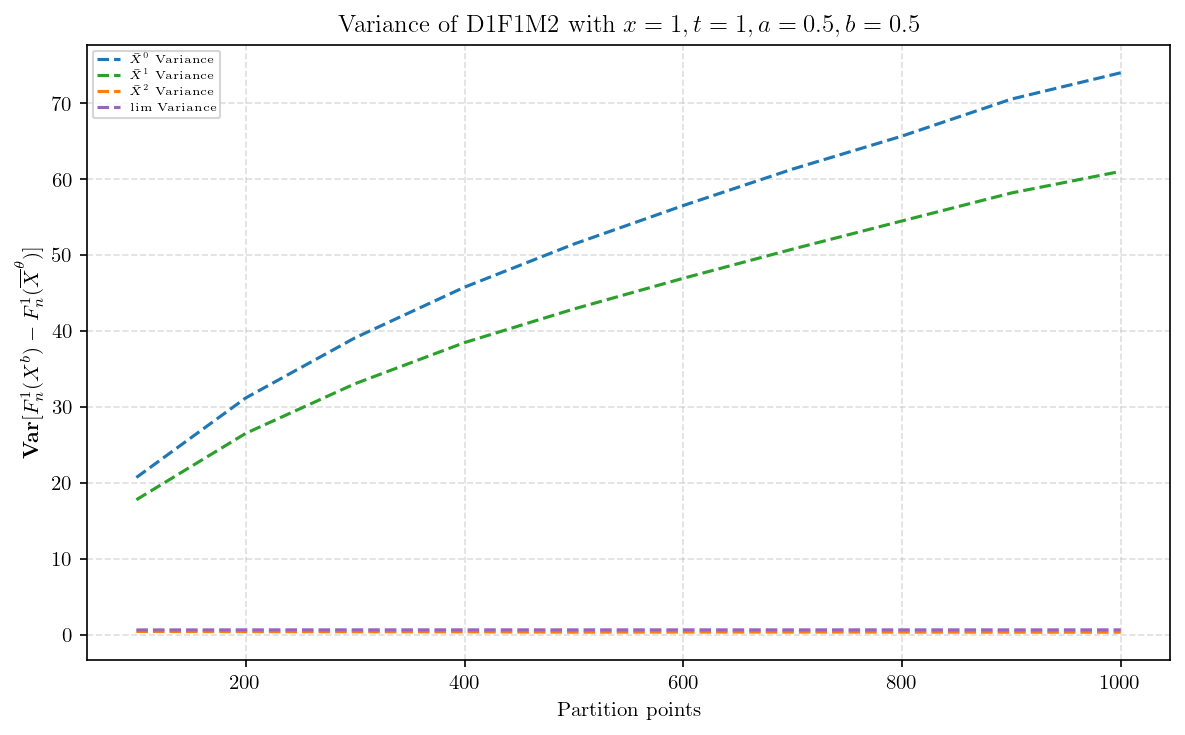

In [39]:
#D1F1M2 variance plot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
plt.rcParams['font.family'] = 'Hiragino Sans'  # 図のフォント設定
df = pd.read_csv("../data_source/D2SM2_all_100_1000_data.csv")

#分散
variance_A = df['E']
variance_Am = df['Em']
variance_A15 = df['E_1_5']
variance_Ab = df['Eb']

plt.figure(figsize=(8, 5), dpi=150)  # dpi とは Dots Per Inch を意味する
plt.plot(df["points"], variance_A, linestyle="--", color="#1f77b4", label=r"$\bar{X}^{0}$ Variance")
plt.plot(df["points"], variance_Am, linestyle="--", color="#2ca02c", label=r"$\bar{X}^{1}$ Variance")
plt.plot(df["points"], variance_A15, linestyle="--", color="#ff7f0e", label=r"$\bar{X}^{2}$ Variance")
plt.plot(df["points"], variance_Ab, linestyle="--", color="#9467bd", label=r"$\lim$ Variance")    
plt.title(r'Variance of D1F1M2 with $x=1,t=1,a=0.5,b=0.5$')
plt.xlabel("Partition points")
plt.ylabel(r'$\mathbf{Var}[F^1_{n}(X^b) - F^1_{n}(\overline{X}^\theta)]$')
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(fontsize=5.5, loc='best')
plt.tight_layout()  # 自動的にレイアウトを調整する
